<a href="https://colab.research.google.com/github/hayatkhan20/umd-urban-heat-exposure/blob/main/notebooks/05_sun_shadow_exposure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import pvlib

# --------------------------------------------------
# Repository and input paths
# --------------------------------------------------

REPO_DIR = Path("/content/umd-urban-heat-exposure")
os.chdir(REPO_DIR)

BOUNDARY_PATH = REPO_DIR / "data/umd_boundary_final.geojson"

BUILDINGS_PATH = (
    REPO_DIR
    / "data/processed/umd_buildings_with_heights_final.geojson"
)

CANOPY_PATH = (
    REPO_DIR
    / "data/processed/umd_canopy_height_naip_chm_1m.tif"
)

for path in [
    BOUNDARY_PATH,
    BUILDINGS_PATH,
    CANOPY_PATH
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")

    print("Found:", path)

# --------------------------------------------------
# Load datasets
# --------------------------------------------------

boundary = gpd.read_file(BOUNDARY_PATH)
buildings = gpd.read_file(BUILDINGS_PATH)

with rasterio.open(CANOPY_PATH) as src:
    canopy_crs = src.crs
    canopy_resolution = src.res
    canopy_width = src.width
    canopy_height = src.height

print("\n--- INPUT DATA CHECK ---")
print("Boundary features:", len(boundary))
print("Buildings:", len(buildings))
print("Canopy CRS:", canopy_crs)
print("Canopy resolution:", canopy_resolution)
print("Canopy dimensions:", canopy_width, "×", canopy_height)

# --------------------------------------------------
# Calculate UMD centre point
# --------------------------------------------------

boundary_utm = boundary.to_crs("EPSG:26918")

boundary_geometry = boundary_utm.geometry.union_all()
centre_utm = boundary_geometry.centroid

centre_wgs84 = gpd.GeoSeries(
    [centre_utm],
    crs=boundary_utm.crs
).to_crs("EPSG:4326").iloc[0]

LONGITUDE = centre_wgs84.x
LATITUDE = centre_wgs84.y
TIMEZONE = "America/New_York"

print("\n--- ANALYSIS LOCATION ---")
print("Latitude:", round(LATITUDE, 6))
print("Longitude:", round(LONGITUDE, 6))
print("Timezone:", TIMEZONE)

# --------------------------------------------------
# Calculate solar positions
# --------------------------------------------------

REFERENCE_DATE = "2026-08-29"

times = pd.date_range(
    start=f"{REFERENCE_DATE} 06:00",
    end=f"{REFERENCE_DATE} 20:00",
    freq="30min",
    tz=TIMEZONE
)

solar_position = pvlib.solarposition.get_solarposition(
    time=times,
    latitude=LATITUDE,
    longitude=LONGITUDE
)

# Retain daylight observations
solar_position = solar_position.loc[
    solar_position["apparent_elevation"] > 0
].copy()

# Shadow direction is opposite the solar azimuth
solar_position["shadow_azimuth"] = (
    solar_position["azimuth"] + 180
) % 360

elevation_radians = np.radians(
    solar_position["apparent_elevation"]
)

# Example shadow lengths for 10 m and 20 m objects
solar_position["shadow_length_10m"] = (
    10 / np.tan(elevation_radians)
)

solar_position["shadow_length_20m"] = (
    20 / np.tan(elevation_radians)
)

# --------------------------------------------------
# Select key analysis hours
# --------------------------------------------------

KEY_HOURS = [9, 12, 15, 18]

key_sun_positions = solar_position.loc[
    (solar_position.index.minute == 0)
    & solar_position.index.hour.isin(KEY_HOURS)
].copy()

columns_to_show = [
    "apparent_elevation",
    "azimuth",
    "shadow_azimuth",
    "shadow_length_10m",
    "shadow_length_20m"
]

print("\n--- KEY SUN POSITIONS ---")
display(key_sun_positions[columns_to_show].round(2))

# --------------------------------------------------
# Save solar-position table
# --------------------------------------------------

SUN_TABLE_PATH = (
    REPO_DIR
    / "data/processed/umd_sun_positions_2026-08-29.csv"
)

solar_export = (
    solar_position
    .reset_index()
    .rename(columns={"index": "time"})
)

solar_export.to_csv(
    SUN_TABLE_PATH,
    index=False
)

print("\nCreated:", SUN_TABLE_PATH)
print("Solar observations:", len(solar_export))

Found: /content/umd-urban-heat-exposure/data/umd_boundary_final.geojson
Found: /content/umd-urban-heat-exposure/data/processed/umd_buildings_with_heights_final.geojson
Found: /content/umd-urban-heat-exposure/data/processed/umd_canopy_height_naip_chm_1m.tif

--- INPUT DATA CHECK ---
Boundary features: 1
Buildings: 3694
Canopy CRS: EPSG:26918
Canopy resolution: (1.0, 1.0)
Canopy dimensions: 4219 × 4738

--- ANALYSIS LOCATION ---
Latitude: 38.989599
Longitude: -76.941666
Timezone: America/New_York

--- KEY SUN POSITIONS ---


,apparent_elevation,azimuth,shadow_azimuth,shadow_length_10m,shadow_length_20m
2026-08-29 09:00:00-04:00,27.36,100.72,280.72,19.33,38.66
2026-08-29 12:00:00-04:00,56.48,148.17,328.17,6.62,13.25
2026-08-29 15:00:00-04:00,51.14,227.28,47.28,8.06,16.12
2026-08-29 18:00:00-04:00,19.06,266.35,86.35,28.95,57.90



Created: /content/umd-urban-heat-exposure/data/processed/umd_sun_positions_2026-08-29.csv
Solar observations: 26


In [15]:
from pathlib import Path
import numpy as np
import geopandas as gpd
import rasterio

from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt

# --------------------------------------------------
# Paths
# --------------------------------------------------

REPO_DIR = Path("/content/umd-urban-heat-exposure")

BOUNDARY_PATH = (
    REPO_DIR / "data/umd_boundary_final.geojson"
)

CANOPY_PATH = (
    REPO_DIR
    / "data/processed/umd_canopy_height_naip_chm_1m.tif"
)

DISTANCE_RASTER_PATH = (
    REPO_DIR
    / "data/processed/umd_distance_to_canopy_1m.tif"
)

# --------------------------------------------------
# Read canopy raster
# --------------------------------------------------

with rasterio.open(CANOPY_PATH) as src:
    canopy_height = src.read(1)
    raster_profile = src.profile.copy()
    raster_transform = src.transform
    raster_crs = src.crs
    raster_shape = (src.height, src.width)

    pixel_width = abs(src.transform.a)
    pixel_height = abs(src.transform.e)

print("--- SOURCE CANOPY ---")
print("CRS:", raster_crs)
print("Resolution:", pixel_width, "×", pixel_height, "m")
print("Shape:", raster_shape)

# Valid canopy is between 2 m and 60 m
canopy_mask = (
    np.isfinite(canopy_height)
    & (canopy_height >= 2)
    & (canopy_height <= 60)
)

print("Canopy pixels:", int(canopy_mask.sum()))

# Release the height array because only the mask is needed here
del canopy_height

# --------------------------------------------------
# Create AOI mask
# --------------------------------------------------

boundary = gpd.read_file(BOUNDARY_PATH).to_crs(
    raster_crs
)

aoi_mask = rasterize(
    [
        (geometry, 1)
        for geometry in boundary.geometry
        if geometry is not None and not geometry.is_empty
    ],
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="uint8",
    all_touched=False
).astype(bool)

print("AOI pixels:", int(aoi_mask.sum()))

# --------------------------------------------------
# Euclidean distance to nearest canopy pixel
# --------------------------------------------------

# distance_transform_edt calculates distance to the
# nearest zero cell. Canopy cells are therefore zero.
distance_to_canopy = distance_transform_edt(
    ~canopy_mask,
    sampling=(pixel_height, pixel_width)
).astype("float32")

# Set pixels outside the UMD boundary to NoData
distance_output = distance_to_canopy.copy()
distance_output[~aoi_mask] = -9999.0

# --------------------------------------------------
# Validate distance values
# --------------------------------------------------

non_canopy_aoi = aoi_mask & ~canopy_mask
valid_distances = distance_to_canopy[non_canopy_aoi]

print("\n--- DISTANCE RASTER CHECK ---")
print("Canopy distance:", 0.0, "m")
print(
    "Minimum non-canopy distance:",
    round(float(valid_distances.min()), 2),
    "m"
)
print(
    "Mean non-canopy distance:",
    round(float(valid_distances.mean()), 2),
    "m"
)
print(
    "Median non-canopy distance:",
    round(float(np.median(valid_distances)), 2),
    "m"
)
print(
    "95th percentile:",
    round(float(np.percentile(valid_distances, 95)), 2),
    "m"
)
print(
    "Maximum distance:",
    round(float(valid_distances.max()), 2),
    "m"
)

# --------------------------------------------------
# Save GeoTIFF
# --------------------------------------------------

raster_profile.update(
    dtype="float32",
    count=1,
    nodata=-9999.0,
    compress="deflate",
    predictor=3,
    tiled=True
)

with rasterio.open(
    DISTANCE_RASTER_PATH,
    "w",
    **raster_profile
) as dst:
    dst.write(distance_output, 1)
    dst.set_band_description(
        1,
        "Euclidean distance to nearest canopy pixel in metres"
    )

print("\nCreated:", DISTANCE_RASTER_PATH)
print(
    "File size:",
    round(
        DISTANCE_RASTER_PATH.stat().st_size / 1024**2,
        2
    ),
    "MiB"
)

--- SOURCE CANOPY ---
CRS: EPSG:26918
Resolution: 1.0 × 1.0 m
Shape: (4738, 4219)
Canopy pixels: 4513362
AOI pixels: 10944844

--- DISTANCE RASTER CHECK ---
Canopy distance: 0.0 m
Minimum non-canopy distance: 1.0 m
Mean non-canopy distance: 10.68 m
Median non-canopy distance: 6.71 m
95th percentile: 33.24 m
Maximum distance: 162.03 m

Created: /content/umd-urban-heat-exposure/data/processed/umd_distance_to_canopy_1m.tif
File size: 9.33 MiB


In [16]:
from scipy import ndimage
from rasterio.features import rasterize

BUILDINGS_PATH = (
    REPO_DIR
    / "data/processed/umd_buildings_with_heights_final.geojson"
)

BUILDING_DISTANCE_PATH = (
    REPO_DIR
    / "data/processed/umd_buildings_with_canopy_distance.geojson"
)

# --------------------------------------------------
# Load distance raster
# --------------------------------------------------

with rasterio.open(DISTANCE_RASTER_PATH) as src:
    distance_array = src.read(1)
    distance_transform = src.transform
    distance_crs = src.crs
    distance_nodata = src.nodata
    distance_shape = (src.height, src.width)

valid_distance = (
    np.isfinite(distance_array)
    & (distance_array != distance_nodata)
)

# --------------------------------------------------
# Load buildings
# --------------------------------------------------

buildings_distance = gpd.read_file(
    BUILDINGS_PATH
).to_crs(distance_crs)

buildings_distance = (
    buildings_distance
    .reset_index(drop=True)
    .copy()
)

# Integer ID for raster calculations
buildings_distance["building_uid"] = (
    np.arange(len(buildings_distance)) + 1
)

# --------------------------------------------------
# Rasterize building IDs
# --------------------------------------------------

building_id_raster = rasterize(
    (
        (geometry, int(building_uid))
        for geometry, building_uid in zip(
            buildings_distance.geometry,
            buildings_distance["building_uid"]
        )
        if geometry is not None
        and not geometry.is_empty
    ),
    out_shape=distance_shape,
    transform=distance_transform,
    fill=0,
    dtype="int32",
    all_touched=True
)

# Remove any building cells outside the AOI
building_id_raster[~valid_distance] = 0

building_ids = buildings_distance[
    "building_uid"
].to_numpy()

# Number of raster cells represented by each building
building_pixel_counts = np.bincount(
    building_id_raster.ravel(),
    minlength=len(buildings_distance) + 1
)[1:]

# Use zero outside valid AOI because these pixels have label 0
distance_working = np.where(
    valid_distance,
    distance_array,
    0
).astype("float32")

# --------------------------------------------------
# Building distance statistics
# --------------------------------------------------

nearest_distances = ndimage.minimum(
    distance_working,
    labels=building_id_raster,
    index=building_ids
)

mean_distances = ndimage.mean(
    distance_working,
    labels=building_id_raster,
    index=building_ids
)

# Canopy overlap: distance equals zero
canopy_overlap_pixels = ndimage.sum(
    (
        valid_distance
        & (distance_array == 0)
    ).astype("uint8"),
    labels=building_id_raster,
    index=building_ids
)

# Buildings not represented in the raster
missing_buildings = building_pixel_counts == 0

nearest_distances = np.asarray(
    nearest_distances,
    dtype="float64"
)

mean_distances = np.asarray(
    mean_distances,
    dtype="float64"
)

nearest_distances[missing_buildings] = np.nan
mean_distances[missing_buildings] = np.nan

canopy_overlap_pct = np.divide(
    canopy_overlap_pixels * 100,
    building_pixel_counts,
    out=np.zeros(
        len(buildings_distance),
        dtype="float64"
    ),
    where=building_pixel_counts > 0
)

# Add results
buildings_distance[
    "nearest_canopy_distance_m"
] = np.round(nearest_distances, 2)

buildings_distance[
    "mean_roof_canopy_distance_m"
] = np.round(mean_distances, 2)

buildings_distance[
    "canopy_overlap_pct"
] = np.round(canopy_overlap_pct, 2)

buildings_distance[
    "building_raster_pixels"
] = building_pixel_counts

# --------------------------------------------------
# Validation
# --------------------------------------------------

valid_nearest = buildings_distance[
    "nearest_canopy_distance_m"
].dropna()

print("--- BUILDING-CANOPY DISTANCE CHECK ---")
print("Input buildings:", len(buildings_distance))
print(
    "Buildings represented:",
    int((building_pixel_counts > 0).sum())
)
print(
    "Buildings not represented:",
    int(missing_buildings.sum())
)
print(
    "Buildings overlapping canopy:",
    int(
        (
            buildings_distance["canopy_overlap_pct"] > 0
        ).sum()
    )
)
print(
    "Nearest-distance minimum:",
    round(float(valid_nearest.min()), 2),
    "m"
)
print(
    "Nearest-distance mean:",
    round(float(valid_nearest.mean()), 2),
    "m"
)
print(
    "Nearest-distance median:",
    round(float(valid_nearest.median()), 2),
    "m"
)
print(
    "Nearest-distance p95:",
    round(
        float(valid_nearest.quantile(0.95)),
        2
    ),
    "m"
)
print(
    "Nearest-distance maximum:",
    round(float(valid_nearest.max()), 2),
    "m"
)

print(
    "Buildings within 5 m:",
    int((valid_nearest <= 5).sum())
)

print(
    "Buildings within 10 m:",
    int((valid_nearest <= 10).sum())
)

print(
    "Buildings farther than 30 m:",
    int((valid_nearest > 30).sum())
)

# --------------------------------------------------
# Export to GeoJSON
# --------------------------------------------------

buildings_output = buildings_distance.to_crs(
    "EPSG:4326"
)

buildings_output.to_file(
    BUILDING_DISTANCE_PATH,
    driver="GeoJSON"
)

print("\nCreated:", BUILDING_DISTANCE_PATH)
print(
    "File size:",
    round(
        BUILDING_DISTANCE_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MiB"
)

/usr/local/lib/python3.13/dist-packages/scipy/ndimage/_measurements.py:810: RuntimeWarning: invalid value encountered in divide
  return sum / np.asanyarray(count).astype(np.float64)


--- BUILDING-CANOPY DISTANCE CHECK ---
Input buildings: 3694
Buildings represented: 3690
Buildings not represented: 4
Buildings overlapping canopy: 3426
Nearest-distance minimum: 0.0 m
Nearest-distance mean: 0.49 m
Nearest-distance median: 0.0 m
Nearest-distance p95: 1.41 m
Nearest-distance maximum: 66.53 m
Buildings within 5 m: 3598
Buildings within 10 m: 3643
Buildings farther than 30 m: 8

Created: /content/umd-urban-heat-exposure/data/processed/umd_buildings_with_canopy_distance.geojson
File size: 3.08 MiB


In [17]:
import geopandas as gpd
from pathlib import Path

BUILDING_DISTANCE_PATH = Path(
    "/content/umd-urban-heat-exposure/"
    "data/processed/"
    "umd_buildings_with_canopy_distance.geojson"
)

distance_buildings = gpd.read_file(
    BUILDING_DISTANCE_PATH
)

overlap = distance_buildings[
    "canopy_overlap_pct"
].dropna()

mean_roof_distance = distance_buildings[
    "mean_roof_canopy_distance_m"
].dropna()

print("--- CANOPY OVERLAP VALIDATION ---")

print("\nCanopy-overlap percentage statistics:")
print(
    overlap.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    ).round(2)
)

print("\nBuildings with overlap greater than 0%:",
      int((overlap > 0).sum()))

print("Buildings with at least 1% overlap:",
      int((overlap >= 1).sum()))

print("Buildings with at least 5% overlap:",
      int((overlap >= 5).sum()))

print("Buildings with at least 10% overlap:",
      int((overlap >= 10).sum()))

print("Buildings with at least 25% overlap:",
      int((overlap >= 25).sum()))

print("Buildings with at least 50% overlap:",
      int((overlap >= 50).sum()))

print("\nMean roof-to-canopy distance statistics:")

print(
    mean_roof_distance.describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    ).round(2)
)

print("\nBuildings with zero nearest distance but less than 1% overlap:")

print(
    int(
        (
            (
                distance_buildings[
                    "nearest_canopy_distance_m"
                ] == 0
            )
            & (
                distance_buildings[
                    "canopy_overlap_pct"
                ] < 1
            )
        ).sum()
    )
)

--- CANOPY OVERLAP VALIDATION ---

Canopy-overlap percentage statistics:
count    3694.00
mean       39.22
std        34.89
min         0.00
25%         8.66
50%        27.64
75%        67.77
90%       100.00
95%       100.00
99%       100.00
max       100.00
Name: canopy_overlap_pct, dtype: float64

Buildings with overlap greater than 0%: 3426
Buildings with at least 1% overlap: 3343
Buildings with at least 5% overlap: 3026
Buildings with at least 10% overlap: 2694
Buildings with at least 25% overlap: 1943
Buildings with at least 50% overlap: 1267

Mean roof-to-canopy distance statistics:
count    3690.00
mean        2.58
std         4.38
min         0.00
25%         0.43
50%         1.46
75%         2.72
90%         6.21
95%         9.49
max        71.50
Name: mean_roof_canopy_distance_m, dtype: float64

Buildings with zero nearest distance but less than 1% overlap:
83


In [18]:
from rasterio.features import geometry_mask
from rasterio.windows import Window
from rasterio.windows import transform as window_transform
from shapely.geometry import mapping
import numpy as np
import geopandas as gpd
import rasterio

# --------------------------------------------------
# Read distance raster
# --------------------------------------------------

with rasterio.open(DISTANCE_RASTER_PATH) as src:
    distance_array = src.read(1)
    distance_transform = src.transform
    distance_crs = src.crs
    distance_nodata = src.nodata
    raster_height = src.height
    raster_width = src.width

# --------------------------------------------------
# Read buildings
# --------------------------------------------------

buildings_corrected = (
    gpd.read_file(BUILDINGS_PATH)
    .to_crs(distance_crs)
    .reset_index(drop=True)
    .copy()
)

buildings_corrected["building_uid"] = (
    np.arange(len(buildings_corrected)) + 1
)

nearest_results = []
mean_results = []
overlap_results = []
pixel_results = []
sampling_methods = []

# --------------------------------------------------
# Process every building independently
# --------------------------------------------------

for index, geometry in enumerate(
    buildings_corrected.geometry
):
    if geometry is None or geometry.is_empty:
        nearest_results.append(np.nan)
        mean_results.append(np.nan)
        overlap_results.append(np.nan)
        pixel_results.append(0)
        sampling_methods.append("missing_geometry")
        continue

    # Convert building bounds to raster coordinates
    left, bottom, right, top = geometry.bounds

    inverse_transform = ~distance_transform

    start_col, start_row = inverse_transform * (
        left,
        top
    )

    end_col, end_row = inverse_transform * (
        right,
        bottom
    )

    row_start = max(
        int(np.floor(min(start_row, end_row))) - 1,
        0
    )

    row_end = min(
        int(np.ceil(max(start_row, end_row))) + 1,
        raster_height
    )

    col_start = max(
        int(np.floor(min(start_col, end_col))) - 1,
        0
    )

    col_end = min(
        int(np.ceil(max(start_col, end_col))) + 1,
        raster_width
    )

    if row_end <= row_start or col_end <= col_start:
        nearest_results.append(np.nan)
        mean_results.append(np.nan)
        overlap_results.append(np.nan)
        pixel_results.append(0)
        sampling_methods.append("outside_raster")
        continue

    window = Window(
        col_start,
        row_start,
        col_end - col_start,
        row_end - row_start
    )

    local_distance = distance_array[
        row_start:row_end,
        col_start:col_end
    ]

    local_transform = window_transform(
        window,
        distance_transform
    )

    valid_local = (
        np.isfinite(local_distance)
        & (local_distance != distance_nodata)
    )

    # Use pixel centres inside the building
    building_mask = geometry_mask(
        [mapping(geometry)],
        out_shape=local_distance.shape,
        transform=local_transform,
        invert=True,
        all_touched=False
    )

    selected = building_mask & valid_local
    sampling_method = "pixel_centre"

    # Fallback only for buildings smaller than one raster cell
    if not selected.any():
        building_mask = geometry_mask(
            [mapping(geometry)],
            out_shape=local_distance.shape,
            transform=local_transform,
            invert=True,
            all_touched=True
        )

        selected = building_mask & valid_local
        sampling_method = "all_touched_fallback"

    if not selected.any():
        nearest_results.append(np.nan)
        mean_results.append(np.nan)
        overlap_results.append(np.nan)
        pixel_results.append(0)
        sampling_methods.append("not_represented")
        continue

    building_values = local_distance[selected]

    nearest_results.append(
        float(building_values.min())
    )

    mean_results.append(
        float(building_values.mean())
    )

    overlap_results.append(
        float(
            (building_values == 0).mean() * 100
        )
    )

    pixel_results.append(
        int(building_values.size)
    )

    sampling_methods.append(sampling_method)

    if (index + 1) % 500 == 0:
        print(
            f"Processed {index + 1} "
            f"of {len(buildings_corrected)} buildings"
        )

# --------------------------------------------------
# Add corrected results
# --------------------------------------------------

buildings_corrected[
    "nearest_canopy_distance_m"
] = np.round(nearest_results, 2)

buildings_corrected[
    "mean_roof_canopy_distance_m"
] = np.round(mean_results, 2)

buildings_corrected[
    "canopy_overlap_pct"
] = np.round(overlap_results, 2)

buildings_corrected[
    "building_raster_pixels"
] = pixel_results

buildings_corrected[
    "distance_sampling_method"
] = sampling_methods

# --------------------------------------------------
# Validate corrected results
# --------------------------------------------------

valid_nearest = buildings_corrected[
    "nearest_canopy_distance_m"
].dropna()

valid_overlap = buildings_corrected[
    "canopy_overlap_pct"
].dropna()

print("\n--- CORRECTED BUILDING DISTANCE CHECK ---")
print("Input buildings:", len(buildings_corrected))
print("Buildings represented:", len(valid_nearest))
print(
    "Buildings not represented:",
    int(buildings_corrected[
        "nearest_canopy_distance_m"
    ].isna().sum())
)
print(
    "Fallback buildings:",
    sampling_methods.count(
        "all_touched_fallback"
    )
)

print(
    "Buildings overlapping canopy:",
    int((valid_overlap > 0).sum())
)
print(
    "Buildings with at least 10% overlap:",
    int((valid_overlap >= 10).sum())
)
print(
    "Buildings with at least 50% overlap:",
    int((valid_overlap >= 50).sum())
)
print(
    "Buildings with 100% overlap:",
    int((valid_overlap == 100).sum())
)

print(
    "Mean overlap:",
    round(float(valid_overlap.mean()), 2),
    "%"
)
print(
    "Median overlap:",
    round(float(valid_overlap.median()), 2),
    "%"
)

print(
    "Nearest-distance mean:",
    round(float(valid_nearest.mean()), 2),
    "m"
)
print(
    "Nearest-distance median:",
    round(float(valid_nearest.median()), 2),
    "m"
)
print(
    "Nearest-distance p95:",
    round(
        float(valid_nearest.quantile(0.95)),
        2
    ),
    "m"
)

# --------------------------------------------------
# Export corrected GeoJSON
# --------------------------------------------------

buildings_corrected.to_crs(
    "EPSG:4326"
).to_file(
    BUILDING_DISTANCE_PATH,
    driver="GeoJSON"
)

print("\nUpdated:", BUILDING_DISTANCE_PATH)

Processed 500 of 3694 buildings
Processed 1000 of 3694 buildings
Processed 1500 of 3694 buildings
Processed 2000 of 3694 buildings
Processed 2500 of 3694 buildings
Processed 3000 of 3694 buildings
Processed 3500 of 3694 buildings

--- CORRECTED BUILDING DISTANCE CHECK ---
Input buildings: 3694
Buildings represented: 3694
Buildings not represented: 0
Fallback buildings: 5
Buildings overlapping canopy: 3099
Buildings with at least 10% overlap: 2205
Buildings with at least 50% overlap: 1164
Buildings with 100% overlap: 522
Mean overlap: 34.82 %
Median overlap: 18.48 %
Nearest-distance mean: 0.62 m
Nearest-distance median: 0.0 m
Nearest-distance p95: 2.0 m

Updated: /content/umd-urban-heat-exposure/data/processed/umd_buildings_with_canopy_distance.geojson


In [19]:
import pandas as pd
import geopandas as gpd

distance_buildings = gpd.read_file(
    BUILDING_DISTANCE_PATH
)

distance_buildings["footprint_area_m2"] = (
    pd.to_numeric(
        distance_buildings["footprint_area_m2"],
        errors="coerce"
    )
)

fully_overlapped = distance_buildings[
    distance_buildings["canopy_overlap_pct"] >= 99.9
].copy()

print("--- FULL CANOPY-OVERLAP BUILDINGS ---")
print("Total:", len(fully_overlapped))

print("\nAll-building footprint area:")
print(
    distance_buildings[
        "footprint_area_m2"
    ].describe().round(2)
)

print("\nFully-overlapped footprint area:")
print(
    fully_overlapped[
        "footprint_area_m2"
    ].describe().round(2)
)

print("\nFully-overlapped buildings by size:")

print(
    "Less than 25 m²:",
    int(
        (
            fully_overlapped[
                "footprint_area_m2"
            ] < 25
        ).sum()
    )
)

print(
    "25–100 m²:",
    int(
        fully_overlapped[
            "footprint_area_m2"
        ].between(25, 100).sum()
    )
)

print(
    "100–250 m²:",
    int(
        fully_overlapped[
            "footprint_area_m2"
        ].between(
            100,
            250,
            inclusive="right"
        ).sum()
    )
)

print(
    "250–500 m²:",
    int(
        fully_overlapped[
            "footprint_area_m2"
        ].between(
            250,
            500,
            inclusive="right"
        ).sum()
    )
)

print(
    "Greater than 500 m²:",
    int(
        (
            fully_overlapped[
                "footprint_area_m2"
            ] > 500
        ).sum()
    )
)

print("\nLargest fully-overlapped buildings:")

display(
    fully_overlapped[
        [
            "id",
            "footprint_area_m2",
            "analysis_height_m",
            "canopy_overlap_pct"
        ]
    ]
    .sort_values(
        "footprint_area_m2",
        ascending=False
    )
    .head(15)
)

--- FULL CANOPY-OVERLAP BUILDINGS ---
Total: 522

All-building footprint area:
count     3694.00
mean       330.91
std       1257.20
min          0.00
25%         22.84
50%        106.21
75%        174.31
max      29101.05
Name: footprint_area_m2, dtype: float64

Fully-overlapped footprint area:
count    522.00
mean      16.94
std       20.76
min        0.00
25%        7.23
50%       10.60
75%       18.64
max      180.30
Name: footprint_area_m2, dtype: float64

Fully-overlapped buildings by size:
Less than 25 m²: 440
25–100 m²: 74
100–250 m²: 8
250–500 m²: 0
Greater than 500 m²: 0

Largest fully-overlapped buildings:


,id,footprint_area_m2,analysis_height_m,canopy_overlap_pct
1624,69a0031b-62f1-4a38-a3e5-d9edb49afd92,180.300119,5.811692,100.0
1998,0bd14dc2-48ad-4d7b-a149-0aa8d8c8b973,172.061492,7.154657,100.0
371,05db4d1e-4140-4ba2-8f32-929a7c9768cb,161.249865,6.880029,100.0
1997,70845eff-fc0a-445b-8a1a-32125383e24a,140.687339,6.498110,100.0
1908,ff0f24e4-6013-4cf8-a8ad-48615cae49cb,126.152191,8.686296,100.0
3346,2f307813-3e16-467b-9fe8-f62a0053aff2,121.446067,8.193428,100.0
2738,79a2d50f-6f09-4efa-a3de-84e7d00a5dd3,115.391484,6.056145,100.0
1871,206a0839-320b-4030-9907-f4bc8922d63b,112.876114,8.026701,100.0
957,f32e29a8-07bf-4cd0-82cd-42980a7965c4,97.548577,3.709156,100.0
3003,d1ecd8bb-70df-4536-9c9e-713c1a7301e4,92.192183,8.001707,100.0


In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from rasterio.features import rasterize
from rasterio.enums import MergeAlg

# --------------------------------------------------
# Paths
# --------------------------------------------------

REPO_DIR = Path("/content/umd-urban-heat-exposure")

BUILDING_DISTANCE_PATH = (
    REPO_DIR
    / "data/processed/umd_buildings_with_canopy_distance.geojson"
)

CANOPY_PATH = (
    REPO_DIR
    / "data/processed/umd_canopy_height_naip_chm_1m.tif"
)

BUILDING_HEIGHT_RASTER_PATH = (
    REPO_DIR
    / "data/processed/umd_building_height_1m.tif"
)

BUILDING_ID_RASTER_PATH = (
    REPO_DIR
    / "data/processed/umd_building_id_1m.tif"
)

# --------------------------------------------------
# Read canopy raster grid
# --------------------------------------------------

with rasterio.open(CANOPY_PATH) as src:
    raster_shape = (src.height, src.width)
    raster_transform = src.transform
    raster_crs = src.crs
    base_profile = src.profile.copy()

    pixel_width = abs(src.transform.a)
    pixel_height = abs(src.transform.e)
    pixel_area_m2 = pixel_width * pixel_height

print("--- REFERENCE GRID ---")
print("CRS:", raster_crs)
print("Shape:", raster_shape)
print(
    "Resolution:",
    pixel_width,
    "×",
    pixel_height,
    "m"
)

# --------------------------------------------------
# Load buildings
# --------------------------------------------------

buildings_roof = (
    gpd.read_file(BUILDING_DISTANCE_PATH)
    .to_crs(raster_crs)
    .reset_index(drop=True)
    .copy()
)

buildings_roof["analysis_height_m"] = (
    pd.to_numeric(
        buildings_roof["analysis_height_m"],
        errors="coerce"
    )
)

if "building_uid" not in buildings_roof.columns:
    buildings_roof["building_uid"] = (
        np.arange(len(buildings_roof)) + 1
    )

valid_buildings = (
    buildings_roof.geometry.notna()
    & ~buildings_roof.geometry.is_empty
    & buildings_roof["analysis_height_m"].notna()
    & (buildings_roof["analysis_height_m"] > 0)
)

invalid_count = int((~valid_buildings).sum())

buildings_roof = buildings_roof.loc[
    valid_buildings
].copy()

# Sort from shortest to tallest.
# Where footprints overlap, the taller roof is retained.
raster_order = buildings_roof.sort_values(
    "analysis_height_m",
    ascending=True
)

print("\n--- BUILDING INPUT ---")
print("Valid buildings:", len(buildings_roof))
print("Invalid buildings:", invalid_count)
print(
    "Buildings below 2 m:",
    int(
        (
            buildings_roof["analysis_height_m"] < 2
        ).sum()
    )
)
print(
    "Minimum height:",
    round(
        float(
            buildings_roof[
                "analysis_height_m"
            ].min()
        ),
        2
    ),
    "m"
)
print(
    "Maximum height:",
    round(
        float(
            buildings_roof[
                "analysis_height_m"
            ].max()
        ),
        2
    ),
    "m"
)

# --------------------------------------------------
# Rasterize building heights
# --------------------------------------------------

building_height_raster = rasterize(
    (
        (geometry, float(height))
        for geometry, height in zip(
            raster_order.geometry,
            raster_order["analysis_height_m"]
        )
    ),
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="float32",
    all_touched=False,
    merge_alg=MergeAlg.replace
)

# --------------------------------------------------
# Rasterize building IDs using the same order
# --------------------------------------------------

building_id_raster = rasterize(
    (
        (geometry, int(building_uid))
        for geometry, building_uid in zip(
            raster_order.geometry,
            raster_order["building_uid"]
        )
    ),
    out_shape=raster_shape,
    transform=raster_transform,
    fill=0,
    dtype="int32",
    all_touched=False,
    merge_alg=MergeAlg.replace
)

roof_mask = building_height_raster > 0
represented_ids = np.unique(
    building_id_raster[building_id_raster > 0]
)

all_ids = set(
    buildings_roof["building_uid"].astype(int)
)

represented_id_set = set(
    represented_ids.astype(int)
)

missing_ids = sorted(
    all_ids - represented_id_set
)

# --------------------------------------------------
# Validate alignment
# --------------------------------------------------

roof_heights = building_height_raster[
    roof_mask
]

raster_roof_area_m2 = (
    int(roof_mask.sum()) * pixel_area_m2
)

vector_footprint_area_m2 = (
    buildings_roof.geometry.area.sum()
)

print("\n--- BUILDING RASTER CHECK ---")
print(
    "Roof pixels:",
    int(roof_mask.sum())
)
print(
    "Buildings represented:",
    len(represented_ids)
)
print(
    "Buildings not represented:",
    len(missing_ids)
)
print(
    "Raster roof area:",
    round(
        raster_roof_area_m2 / 1_000_000,
        3
    ),
    "km²"
)
print(
    "Vector footprint-area sum:",
    round(
        vector_footprint_area_m2 / 1_000_000,
        3
    ),
    "km²"
)
print(
    "Pixel-weighted mean roof height:",
    round(
        float(roof_heights.mean()),
        2
    ),
    "m"
)
print(
    "Raster minimum roof height:",
    round(
        float(roof_heights.min()),
        2
    ),
    "m"
)
print(
    "Raster maximum roof height:",
    round(
        float(roof_heights.max()),
        2
    ),
    "m"
)

if missing_ids:
    print(
        "First missing building IDs:",
        missing_ids[:20]
    )

# --------------------------------------------------
# Save building-height raster
# --------------------------------------------------

height_profile = base_profile.copy()

height_profile.update(
    dtype="float32",
    count=1,
    nodata=0,
    compress="deflate",
    predictor=3,
    tiled=True
)

with rasterio.open(
    BUILDING_HEIGHT_RASTER_PATH,
    "w",
    **height_profile
) as dst:
    dst.write(building_height_raster, 1)
    dst.set_band_description(
        1,
        "Building roof height above ground in metres"
    )

# --------------------------------------------------
# Save building-ID raster
# --------------------------------------------------

id_profile = base_profile.copy()

id_profile.update(
    dtype="int32",
    count=1,
    nodata=0,
    compress="deflate",
    predictor=2,
    tiled=True
)

with rasterio.open(
    BUILDING_ID_RASTER_PATH,
    "w",
    **id_profile
) as dst:
    dst.write(building_id_raster, 1)
    dst.set_band_description(
        1,
        "Internal building UID"
    )

print("\nCreated:", BUILDING_HEIGHT_RASTER_PATH)
print("Created:", BUILDING_ID_RASTER_PATH)

print(
    "Height-raster size:",
    round(
        BUILDING_HEIGHT_RASTER_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MiB"
)

print(
    "ID-raster size:",
    round(
        BUILDING_ID_RASTER_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MiB"
)

--- REFERENCE GRID ---
CRS: EPSG:26918
Shape: (4738, 4219)
Resolution: 1.0 × 1.0 m

--- BUILDING INPUT ---
Valid buildings: 3694
Invalid buildings: 0
Buildings below 2 m: 90
Minimum height: 1.51 m
Maximum height: 69.51 m

--- BUILDING RASTER CHECK ---
Roof pixels: 1215002
Buildings represented: 3687
Buildings not represented: 7
Raster roof area: 1.215 km²
Vector footprint-area sum: 1.222 km²
Pixel-weighted mean roof height: 11.87 m
Raster minimum roof height: 1.51 m
Raster maximum roof height: 69.51 m
First missing building IDs: [76, 696, 1189, 1255, 1764, 3118, 3216]

Created: /content/umd-urban-heat-exposure/data/processed/umd_building_height_1m.tif
Created: /content/umd-urban-heat-exposure/data/processed/umd_building_id_1m.tif
Height-raster size: 0.79 MiB
ID-raster size: 0.33 MiB


In [21]:
import numpy as np
import pandas as pd
import rasterio
from pathlib import Path

# --------------------------------------------------
# Paths
# --------------------------------------------------

SUN_TABLE_PATH = (
    REPO_DIR
    / "data/processed/umd_sun_positions_2026-08-29.csv"
)

NOON_SHADOW_PATH = (
    REPO_DIR
    / "data/processed/umd_roof_exposure_2026-08-29_1200.tif"
)

# --------------------------------------------------
# Load aligned rasters
# --------------------------------------------------

with rasterio.open(CANOPY_PATH) as src:
    canopy_height = src.read(1).astype("float32")
    reference_profile = src.profile.copy()
    reference_transform = src.transform
    reference_crs = src.crs
    pixel_width = abs(src.transform.a)
    pixel_height = abs(src.transform.e)

with rasterio.open(
    BUILDING_HEIGHT_RASTER_PATH
) as src:
    roof_height = src.read(1).astype("float32")

    assert src.crs == reference_crs
    assert src.transform == reference_transform
    assert src.shape == canopy_height.shape

with rasterio.open(
    BUILDING_ID_RASTER_PATH
) as src:
    roof_building_id = src.read(1).astype("int32")

    assert src.crs == reference_crs
    assert src.transform == reference_transform
    assert src.shape == canopy_height.shape

# Valid canopy
canopy_height[
    (~np.isfinite(canopy_height))
    | (canopy_height < 2)
    | (canopy_height > 60)
] = 0

roof_mask = (
    (roof_height > 0)
    & (roof_building_id > 0)
)

# --------------------------------------------------
# Read precise noon solar position
# --------------------------------------------------

sun_table = pd.read_csv(SUN_TABLE_PATH)

time_column = sun_table.columns[0]

sun_table["local_time"] = (
    pd.to_datetime(
        sun_table[time_column],
        utc=True
    )
    .dt.tz_convert("America/New_York")
)

noon_record = sun_table.loc[
    (sun_table["local_time"].dt.hour == 12)
    & (sun_table["local_time"].dt.minute == 0)
].iloc[0]

solar_elevation = float(
    noon_record["apparent_elevation"]
)

shadow_azimuth = float(
    noon_record["shadow_azimuth"]
)

elevation_tangent = np.tan(
    np.radians(solar_elevation)
)

maximum_canopy_height = float(
    canopy_height.max()
)

maximum_shadow_length = (
    maximum_canopy_height
    / elevation_tangent
)

print("--- NOON SOLAR GEOMETRY ---")
print(
    "Solar elevation:",
    round(solar_elevation, 2),
    "degrees"
)
print(
    "Shadow azimuth:",
    round(shadow_azimuth, 2),
    "degrees"
)
print(
    "Maximum possible canopy shadow:",
    round(maximum_shadow_length, 2),
    "m"
)

# --------------------------------------------------
# Create directional raster offsets
# --------------------------------------------------

azimuth_radians = np.radians(
    shadow_azimuth
)

offsets = {}
sample_step_m = 0.5

for sample_distance in np.arange(
    0,
    maximum_shadow_length + sample_step_m,
    sample_step_m
):
    east_distance = (
        sample_distance
        * np.sin(azimuth_radians)
    )

    north_distance = (
        sample_distance
        * np.cos(azimuth_radians)
    )

    column_offset = int(
        np.rint(
            east_distance / pixel_width
        )
    )

    # Raster rows increase toward the south
    row_offset = int(
        np.rint(
            -north_distance / pixel_height
        )
    )

    actual_distance = np.hypot(
        column_offset * pixel_width,
        row_offset * pixel_height
    )

    if (
        actual_distance
        <= maximum_shadow_length + 0.75
    ):
        offsets[
            (row_offset, column_offset)
        ] = actual_distance

directional_offsets = sorted(
    [
        (row_offset, column_offset, distance)
        for (
            row_offset,
            column_offset
        ), distance in offsets.items()
    ],
    key=lambda item: item[2]
)

print(
    "Directional offsets:",
    len(directional_offsets)
)

# --------------------------------------------------
# Test every roof pixel against up-sun canopy
# --------------------------------------------------

roof_rows, roof_columns = np.where(
    roof_mask
)

roof_pixel_heights = roof_height[
    roof_rows,
    roof_columns
]

roof_is_shaded = np.zeros(
    len(roof_rows),
    dtype=bool
)

raster_height, raster_width = (
    canopy_height.shape
)

for offset_number, (
    row_offset,
    column_offset,
    horizontal_distance
) in enumerate(
    directional_offsets,
    start=1
):
    # Source canopy lies opposite the shadow offset
    source_rows = (
        roof_rows - row_offset
    )

    source_columns = (
        roof_columns - column_offset
    )

    inside_raster = (
        (source_rows >= 0)
        & (source_rows < raster_height)
        & (source_columns >= 0)
        & (source_columns < raster_width)
        & ~roof_is_shaded
    )

    candidate_indices = np.where(
        inside_raster
    )[0]

    if candidate_indices.size == 0:
        continue

    candidate_canopy_height = canopy_height[
        source_rows[candidate_indices],
        source_columns[candidate_indices]
    ]

    required_canopy_height = (
        roof_pixel_heights[
            candidate_indices
        ]
        + horizontal_distance
        * elevation_tangent
    )

    newly_shaded = (
        candidate_canopy_height
        > required_canopy_height
    )

    roof_is_shaded[
        candidate_indices[newly_shaded]
    ] = True

# --------------------------------------------------
# Create roof exposure raster
# --------------------------------------------------

# 0 = not a roof
# 1 = sun-exposed roof
# 2 = tree-shaded roof

roof_exposure = np.zeros(
    canopy_height.shape,
    dtype="uint8"
)

roof_exposure[
    roof_rows,
    roof_columns
] = 1

roof_exposure[
    roof_rows[roof_is_shaded],
    roof_columns[roof_is_shaded]
] = 2

total_roof_pixels = len(roof_rows)

shaded_roof_pixels = int(
    roof_is_shaded.sum()
)

exposed_roof_pixels = (
    total_roof_pixels
    - shaded_roof_pixels
)

shaded_percentage = (
    shaded_roof_pixels
    / total_roof_pixels
    * 100
)

exposed_percentage = (
    exposed_roof_pixels
    / total_roof_pixels
    * 100
)

# Buildings with at least one shaded roof pixel
shaded_building_ids = np.unique(
    roof_building_id[
        roof_exposure == 2
    ]
)

shaded_building_ids = shaded_building_ids[
    shaded_building_ids > 0
]

print("\n--- NOON ROOF EXPOSURE CHECK ---")
print(
    "Total roof area:",
    round(
        total_roof_pixels
        * pixel_width
        * pixel_height
        / 1_000_000,
        3
    ),
    "km²"
)
print(
    "Tree-shaded roof area:",
    round(
        shaded_roof_pixels
        * pixel_width
        * pixel_height
        / 1_000_000,
        3
    ),
    "km²"
)
print(
    "Sun-exposed roof area:",
    round(
        exposed_roof_pixels
        * pixel_width
        * pixel_height
        / 1_000_000,
        3
    ),
    "km²"
)
print(
    "Tree-shaded roof:",
    round(shaded_percentage, 2),
    "%"
)
print(
    "Sun-exposed roof:",
    round(exposed_percentage, 2),
    "%"
)
print(
    "Buildings receiving some tree shade:",
    len(shaded_building_ids)
)

# --------------------------------------------------
# Save test raster
# --------------------------------------------------

shadow_profile = reference_profile.copy()

shadow_profile.update(
    dtype="uint8",
    count=1,
    nodata=0,
    compress="deflate",
    predictor=2,
    tiled=True
)

with rasterio.open(
    NOON_SHADOW_PATH,
    "w",
    **shadow_profile
) as dst:
    dst.write(roof_exposure, 1)

    dst.set_band_description(
        1,
        "0 non-roof, 1 exposed roof, 2 tree-shaded roof"
    )

print("\nCreated:", NOON_SHADOW_PATH)
print(
    "File size:",
    round(
        NOON_SHADOW_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MiB"
)

--- NOON SOLAR GEOMETRY ---
Solar elevation: 56.48 degrees
Shadow azimuth: 328.17 degrees
Maximum possible canopy shadow: 38.11 m
Directional offsets: 46

--- NOON ROOF EXPOSURE CHECK ---
Total roof area: 1.215 km²
Tree-shaded roof area: 0.079 km²
Sun-exposed roof area: 1.136 km²
Tree-shaded roof: 6.49 %
Sun-exposed roof: 93.51 %
Buildings receiving some tree shade: 2400

Created: /content/umd-urban-heat-exposure/data/processed/umd_roof_exposure_2026-08-29_1200.tif
File size: 0.2 MiB


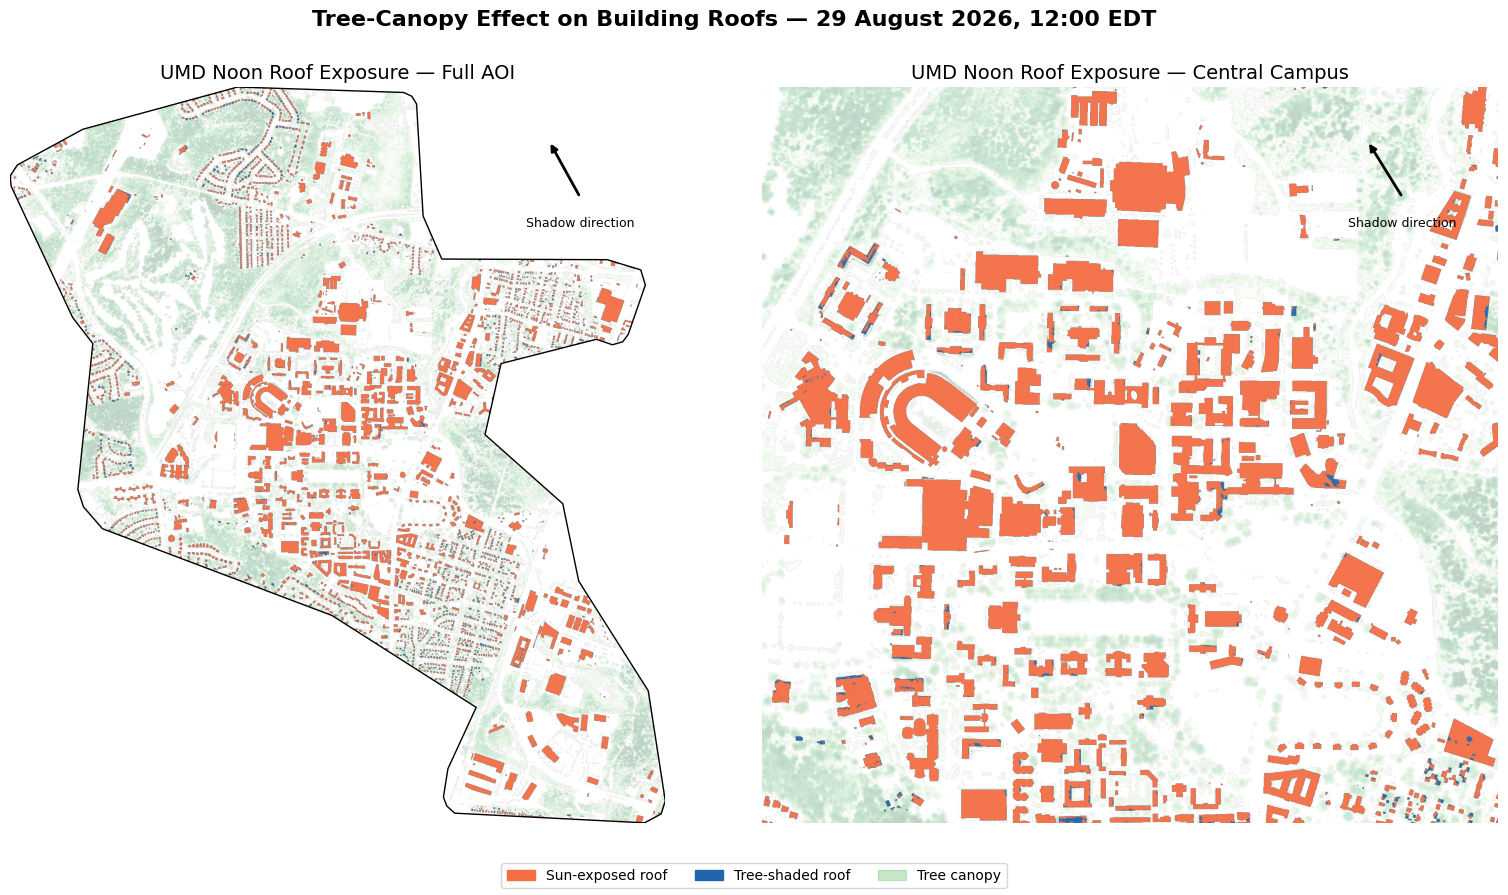

Created: /content/umd-urban-heat-exposure/outputs/figures/umd_noon_roof_exposure.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.transform import array_bounds

# --------------------------------------------------
# Reload noon exposure raster
# --------------------------------------------------

with rasterio.open(NOON_SHADOW_PATH) as src:
    noon_exposure = src.read(1)
    plot_transform = src.transform
    plot_crs = src.crs

with rasterio.open(CANOPY_PATH) as src:
    canopy_plot = src.read(1)

boundary_plot = gpd.read_file(
    BOUNDARY_PATH
).to_crs(plot_crs)

west, south, east, north = array_bounds(
    noon_exposure.shape[0],
    noon_exposure.shape[1],
    plot_transform
)

extent = [west, east, south, north]

# Mask non-canopy and non-building pixels
canopy_display = np.ma.masked_where(
    canopy_plot < 2,
    canopy_plot
)

exposure_display = np.ma.masked_where(
    noon_exposure == 0,
    noon_exposure
)

exposure_cmap = ListedColormap(
    [
        "#f46d43",  # exposed roof
        "#2166ac"   # tree-shaded roof
    ]
)

exposure_norm = BoundaryNorm(
    [0.5, 1.5, 2.5],
    exposure_cmap.N
)

# Central-campus zoom
campus_centre = (
    boundary_plot.geometry
    .union_all()
    .centroid
)

zoom_distance = 900

zoom_bounds = [
    campus_centre.x - zoom_distance,
    campus_centre.x + zoom_distance,
    campus_centre.y - zoom_distance,
    campus_centre.y + zoom_distance
]

# Shadow-direction vector
azimuth_radians = np.radians(
    shadow_azimuth
)

arrow_dx = np.sin(azimuth_radians)
arrow_dy = np.cos(azimuth_radians)

# --------------------------------------------------
# Plot full AOI and central-campus detail
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 9)
)

for ax in axes:
    ax.imshow(
        canopy_display,
        extent=extent,
        origin="upper",
        cmap="Greens",
        vmin=2,
        vmax=30,
        alpha=0.25
    )

    ax.imshow(
        exposure_display,
        extent=extent,
        origin="upper",
        cmap=exposure_cmap,
        norm=exposure_norm,
        alpha=0.95
    )

    boundary_plot.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1
    )

    # Shadow-direction arrow
    arrow_start_x = 0.87
    arrow_start_y = 0.85
    arrow_length = 0.09

    ax.annotate(
        "",
        xy=(
            arrow_start_x
            + arrow_dx * arrow_length,
            arrow_start_y
            + arrow_dy * arrow_length
        ),
        xytext=(
            arrow_start_x,
            arrow_start_y
        ),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            color="black",
            linewidth=2
        )
    )

    ax.text(
        arrow_start_x,
        arrow_start_y - 0.04,
        "Shadow direction",
        transform=ax.transAxes,
        ha="center",
        fontsize=9
    )

    ax.set_aspect("equal")
    ax.set_axis_off()

axes[0].set_title(
    "UMD Noon Roof Exposure — Full AOI",
    fontsize=14
)

axes[1].set_xlim(
    zoom_bounds[0],
    zoom_bounds[1]
)

axes[1].set_ylim(
    zoom_bounds[2],
    zoom_bounds[3]
)

axes[1].set_title(
    "UMD Noon Roof Exposure — Central Campus",
    fontsize=14
)

legend_items = [
    mpatches.Patch(
        color="#f46d43",
        label="Sun-exposed roof"
    ),
    mpatches.Patch(
        color="#2166ac",
        label="Tree-shaded roof"
    ),
    mpatches.Patch(
        color="#74c476",
        alpha=0.4,
        label="Tree canopy"
    )
]

fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=3,
    frameon=True
)

fig.suptitle(
    "Tree-Canopy Effect on Building Roofs — "
    "29 August 2026, 12:00 EDT",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.95])

FIGURE_DIRECTORY = (
    REPO_DIR / "outputs/figures"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

NOON_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "umd_noon_roof_exposure.png"
)

plt.savefig(
    NOON_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Created:", NOON_FIGURE_PATH)

In [23]:
import numpy as np
import geopandas as gpd

from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry.polygon import orient

FACADE_STEP_M = 1.0

FACADE_SAMPLE_PATH = (
    REPO_DIR
    / "data/processed/umd_facade_samples_1m.npz"
)

# --------------------------------------------------
# Load buildings
# --------------------------------------------------

facade_buildings = (
    gpd.read_file(BUILDING_DISTANCE_PATH)
    .to_crs("EPSG:26918")
    .reset_index(drop=True)
    .copy()
)

if "building_uid" not in facade_buildings.columns:
    facade_buildings["building_uid"] = (
        np.arange(len(facade_buildings)) + 1
    )

facade_buildings["analysis_height_m"] = (
    pd.to_numeric(
        facade_buildings["analysis_height_m"],
        errors="coerce"
    )
)

# Arrays will be assembled in chunks
x_chunks = []
y_chunks = []
normal_x_chunks = []
normal_y_chunks = []
length_chunks = []
height_chunks = []
uid_chunks = []

# --------------------------------------------------
# Generate exterior façade segments
# --------------------------------------------------

for building_index, row in facade_buildings.iterrows():

    geometry = row.geometry
    building_height = float(
        row["analysis_height_m"]
    )
    building_uid = int(
        row["building_uid"]
    )

    if (
        geometry is None
        or geometry.is_empty
        or not np.isfinite(building_height)
        or building_height <= 0
    ):
        continue

    if isinstance(geometry, Polygon):
        polygon_parts = [geometry]

    elif isinstance(geometry, MultiPolygon):
        polygon_parts = list(geometry.geoms)

    else:
        continue

    for polygon in polygon_parts:

        # Ensure exterior ring is counter-clockwise
        polygon = orient(
            polygon,
            sign=1.0
        )

        coordinates = np.asarray(
            polygon.exterior.coords,
            dtype="float64"
        )

        for coordinate_index in range(
            len(coordinates) - 1
        ):

            x1, y1 = coordinates[
                coordinate_index
            ]

            x2, y2 = coordinates[
                coordinate_index + 1
            ]

            delta_x = x2 - x1
            delta_y = y2 - y1

            edge_length = np.hypot(
                delta_x,
                delta_y
            )

            if edge_length <= 0:
                continue

            number_of_segments = max(
                1,
                int(
                    np.ceil(
                        edge_length
                        / FACADE_STEP_M
                    )
                )
            )

            segment_length = (
                edge_length
                / number_of_segments
            )

            segment_positions = (
                np.arange(
                    number_of_segments,
                    dtype="float64"
                )
                + 0.5
            ) / number_of_segments

            segment_x = (
                x1
                + segment_positions
                * delta_x
            )

            segment_y = (
                y1
                + segment_positions
                * delta_y
            )

            # For a counter-clockwise polygon,
            # the right-hand normal points outward
            outward_normal_x = (
                delta_y / edge_length
            )

            outward_normal_y = (
                -delta_x / edge_length
            )

            x_chunks.append(segment_x)
            y_chunks.append(segment_y)

            normal_x_chunks.append(
                np.full(
                    number_of_segments,
                    outward_normal_x,
                    dtype="float32"
                )
            )

            normal_y_chunks.append(
                np.full(
                    number_of_segments,
                    outward_normal_y,
                    dtype="float32"
                )
            )

            length_chunks.append(
                np.full(
                    number_of_segments,
                    segment_length,
                    dtype="float32"
                )
            )

            height_chunks.append(
                np.full(
                    number_of_segments,
                    building_height,
                    dtype="float32"
                )
            )

            uid_chunks.append(
                np.full(
                    number_of_segments,
                    building_uid,
                    dtype="int32"
                )
            )

    if (building_index + 1) % 500 == 0:
        print(
            f"Processed {building_index + 1} "
            f"of {len(facade_buildings)} buildings"
        )

# --------------------------------------------------
# Combine chunks
# --------------------------------------------------

facade_x = np.concatenate(
    x_chunks
).astype("float64")

facade_y = np.concatenate(
    y_chunks
).astype("float64")

facade_normal_x = np.concatenate(
    normal_x_chunks
)

facade_normal_y = np.concatenate(
    normal_y_chunks
)

facade_segment_length = np.concatenate(
    length_chunks
)

facade_building_height = np.concatenate(
    height_chunks
)

facade_building_uid = np.concatenate(
    uid_chunks
)

# Each segment represents a complete vertical wall strip
facade_segment_area = (
    facade_segment_length
    * facade_building_height
)

# --------------------------------------------------
# Validation
# --------------------------------------------------

represented_facade_ids = np.unique(
    facade_building_uid
)

print("\n--- FACADE SAMPLE CHECK ---")
print(
    "Buildings represented:",
    len(represented_facade_ids)
)
print(
    "Façade segments:",
    len(facade_x)
)
print(
    "Total exterior wall length:",
    round(
        float(
            facade_segment_length.sum()
        ) / 1000,
        2
    ),
    "km"
)
print(
    "Total façade area:",
    round(
        float(
            facade_segment_area.sum()
        ) / 1_000_000,
        3
    ),
    "km²"
)
print(
    "Mean segment length:",
    round(
        float(
            facade_segment_length.mean()
        ),
        3
    ),
    "m"
)
print(
    "Maximum segment length:",
    round(
        float(
            facade_segment_length.max()
        ),
        3
    ),
    "m"
)

# --------------------------------------------------
# Save arrays for the exposure analysis
# --------------------------------------------------

np.savez_compressed(
    FACADE_SAMPLE_PATH,
    x=facade_x,
    y=facade_y,
    normal_x=facade_normal_x,
    normal_y=facade_normal_y,
    segment_length=facade_segment_length,
    building_height=facade_building_height,
    building_uid=facade_building_uid
)

print("\nCreated:", FACADE_SAMPLE_PATH)
print(
    "File size:",
    round(
        FACADE_SAMPLE_PATH.stat().st_size
        / 1024**2,
        2
    ),
    "MiB"
)

Processed 500 of 3694 buildings
Processed 1000 of 3694 buildings
Processed 1500 of 3694 buildings
Processed 2000 of 3694 buildings
Processed 2500 of 3694 buildings
Processed 3000 of 3694 buildings
Processed 3500 of 3694 buildings

--- FACADE SAMPLE CHECK ---
Buildings represented: 3694
Façade segments: 228759
Total exterior wall length: 213.73 km
Total façade area: 1.939 km²
Mean segment length: 0.934 m
Maximum segment length: 1.0 m

Created: /content/umd-urban-heat-exposure/data/processed/umd_facade_samples_1m.npz
File size: 2.83 MiB


In [24]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

from pathlib import Path

# --------------------------------------------------
# Paths and inputs
# --------------------------------------------------

EXPOSURE_GEOJSON_PATH = (
    REPO_DIR
    / "data/processed/umd_building_solar_exposure_2026-08-29.geojson"
)

EXPOSURE_CSV_PATH = (
    REPO_DIR
    / "data/processed/umd_building_solar_exposure_2026-08-29.csv"
)

ROOF_RASTER_DIRECTORY = (
    REPO_DIR / "data/processed/roof_exposure"
)

ROOF_RASTER_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

with rasterio.open(CANOPY_PATH) as src:
    canopy = src.read(1).astype("float32")
    raster_transform = src.transform
    raster_crs = src.crs
    raster_profile = src.profile.copy()
    pixel_area_m2 = abs(
        src.transform.a * src.transform.e
    )

with rasterio.open(BUILDING_HEIGHT_RASTER_PATH) as src:
    roof_height = src.read(1).astype("float32")

with rasterio.open(BUILDING_ID_RASTER_PATH) as src:
    roof_id = src.read(1).astype("int32")

canopy[
    (~np.isfinite(canopy))
    | (canopy < 2)
    | (canopy > 60)
] = 0

# Load façade samples
facade_data = np.load(FACADE_SAMPLE_PATH)

facade_x = facade_data["x"]
facade_y = facade_data["y"]
facade_normal_x = facade_data["normal_x"]
facade_normal_y = facade_data["normal_y"]
facade_length = facade_data["segment_length"]
facade_height = facade_data["building_height"]
facade_uid = facade_data["building_uid"].astype("int32")

# Load buildings
exposure_buildings = (
    gpd.read_file(BUILDING_DISTANCE_PATH)
    .to_crs(raster_crs)
    .reset_index(drop=True)
    .copy()
)

uid_order = exposure_buildings[
    "building_uid"
].astype(int).to_numpy()

maximum_uid = int(uid_order.max())
array_length = maximum_uid + 1

# Exact roof area from vector geometry
roof_area_by_uid = np.zeros(
    array_length,
    dtype="float64"
)

roof_area_by_uid[uid_order] = (
    exposure_buildings.geometry.area.to_numpy()
)

# Total façade area
facade_area_by_uid = np.bincount(
    facade_uid,
    weights=facade_length * facade_height,
    minlength=array_length
)

envelope_area_by_uid = (
    roof_area_by_uid
    + facade_area_by_uid
)

# Raster roof coordinates
roof_mask = (
    (roof_height > 0)
    & (roof_id > 0)
)

roof_rows, roof_columns = np.where(
    roof_mask
)

roof_pixel_height = roof_height[
    roof_rows,
    roof_columns
]

roof_pixel_uid = roof_id[
    roof_rows,
    roof_columns
]

roof_pixel_count_by_uid = np.bincount(
    roof_pixel_uid,
    minlength=array_length
)

# Façade locations converted to raster indices
assert raster_transform.b == 0
assert raster_transform.d == 0

facade_columns = np.floor(
    (
        facade_x
        - raster_transform.c
    ) / raster_transform.a
).astype("int32")

facade_rows = np.floor(
    (
        facade_y
        - raster_transform.f
    ) / raster_transform.e
).astype("int32")

raster_height, raster_width = canopy.shape
maximum_canopy_height = float(canopy.max())

# --------------------------------------------------
# Solar positions
# --------------------------------------------------

sun_table = pd.read_csv(SUN_TABLE_PATH)
time_column = sun_table.columns[0]

sun_table["local_time"] = (
    pd.to_datetime(
        sun_table[time_column],
        utc=True
    )
    .dt.tz_convert("America/New_York")
)

key_hours = [9, 12, 15, 18]

key_sun = sun_table.loc[
    (sun_table["local_time"].dt.minute == 0)
    & (
        sun_table[
            "local_time"
        ].dt.hour.isin(key_hours)
    )
].copy()

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def safe_divide(numerator, denominator):
    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(
            numerator,
            dtype="float64"
        ),
        where=denominator > 0
    )


def create_sun_offsets(
    solar_elevation,
    solar_azimuth
):
    tangent_elevation = np.tan(
        np.radians(solar_elevation)
    )

    maximum_distance = (
        maximum_canopy_height
        / tangent_elevation
    )

    azimuth_radians = np.radians(
        solar_azimuth
    )

    offsets = {}

    for distance in np.arange(
        0,
        maximum_distance + 0.5,
        0.5
    ):
        column_offset = int(
            np.rint(
                distance
                * np.sin(azimuth_radians)
            )
        )

        row_offset = int(
            np.rint(
                -distance
                * np.cos(azimuth_radians)
            )
        )

        actual_distance = np.hypot(
            column_offset,
            row_offset
        )

        if (
            actual_distance
            <= maximum_distance + 0.75
        ):
            offsets[
                (row_offset, column_offset)
            ] = actual_distance

    offset_list = sorted(
        [
            (row, column, distance)
            for (
                row,
                column
            ), distance in offsets.items()
        ],
        key=lambda item: item[2]
    )

    return (
        offset_list,
        tangent_elevation,
        maximum_distance
    )


def calculate_roof_shade(
    offsets,
    tangent_elevation
):
    shaded = np.zeros(
        len(roof_rows),
        dtype=bool
    )

    for (
        row_offset,
        column_offset,
        distance
    ) in offsets:

        source_rows = (
            roof_rows + row_offset
        )

        source_columns = (
            roof_columns + column_offset
        )

        valid = (
            ~shaded
            & (source_rows >= 0)
            & (source_rows < raster_height)
            & (source_columns >= 0)
            & (source_columns < raster_width)
        )

        candidate = np.where(valid)[0]

        if candidate.size == 0:
            continue

        source_canopy = canopy[
            source_rows[candidate],
            source_columns[candidate]
        ]

        required_height = (
            roof_pixel_height[candidate]
            + distance
            * tangent_elevation
        )

        newly_shaded = (
            source_canopy
            > required_height
        )

        shaded[
            candidate[newly_shaded]
        ] = True

    return shaded


def calculate_facade_shadow_height(
    offsets,
    tangent_elevation,
    sun_facing
):
    shadow_height = np.zeros(
        len(facade_uid),
        dtype="float32"
    )

    for (
        row_offset,
        column_offset,
        distance
    ) in offsets:

        source_rows = (
            facade_rows + row_offset
        )

        source_columns = (
            facade_columns + column_offset
        )

        # Stop checking segments already shaded
        # across their complete height
        valid = (
            sun_facing
            & (shadow_height < facade_height)
            & (source_rows >= 0)
            & (source_rows < raster_height)
            & (source_columns >= 0)
            & (source_columns < raster_width)
        )

        candidate = np.where(valid)[0]

        if candidate.size == 0:
            continue

        source_canopy = canopy[
            source_rows[candidate],
            source_columns[candidate]
        ]

        projected_shadow_height = (
            source_canopy
            - distance
            * tangent_elevation
        )

        shadow_height[candidate] = np.maximum(
            shadow_height[candidate],
            projected_shadow_height
        )

    return np.clip(
        shadow_height,
        0,
        facade_height
    )


# --------------------------------------------------
# Run all four timestamps
# --------------------------------------------------

time_results = {}
exposure_raster_paths = []

for _, solar_record in key_sun.iterrows():

    local_time = solar_record["local_time"]
    hour = int(local_time.hour)
    suffix = f"{hour:02d}00"

    solar_elevation = float(
        solar_record["apparent_elevation"]
    )

    solar_azimuth = float(
        solar_record["azimuth"]
    )

    shadow_azimuth = float(
        solar_record["shadow_azimuth"]
    )

    (
        offsets,
        tangent_elevation,
        maximum_distance
    ) = create_sun_offsets(
        solar_elevation,
        solar_azimuth
    )

    print(
        f"\nProcessing {suffix}: "
        f"elevation={solar_elevation:.2f}°, "
        f"azimuth={solar_azimuth:.2f}°, "
        f"maximum shadow={maximum_distance:.2f} m"
    )

    # ----------------------------------------------
    # Roof exposure
    # ----------------------------------------------

    roof_shaded = calculate_roof_shade(
        offsets,
        tangent_elevation
    )

    shaded_roof_pixels_by_uid = np.bincount(
        roof_pixel_uid[roof_shaded],
        minlength=array_length
    )

    roof_shaded_fraction = safe_divide(
        shaded_roof_pixels_by_uid,
        roof_pixel_count_by_uid
    )

    # Seven tiny/non-represented roofs:
    # use their existing canopy-overlap fraction
    missing_roof_uids = np.where(
        (
            roof_area_by_uid > 0
        )
        & (
            roof_pixel_count_by_uid == 0
        )
    )[0]

    if len(missing_roof_uids) > 0:
        overlap_lookup = dict(
            zip(
                uid_order,
                exposure_buildings[
                    "canopy_overlap_pct"
                ].fillna(0).to_numpy()
                / 100
            )
        )

        for missing_uid in missing_roof_uids:
            roof_shaded_fraction[
                missing_uid
            ] = overlap_lookup.get(
                missing_uid,
                0
            )

    roof_shaded_area = (
        roof_area_by_uid
        * roof_shaded_fraction
    )

    roof_exposed_area = (
        roof_area_by_uid
        - roof_shaded_area
    )

    # ----------------------------------------------
    # Façade orientation and exposure
    # ----------------------------------------------

    azimuth_radians = np.radians(
        solar_azimuth
    )

    sun_direction_x = np.sin(
        azimuth_radians
    )

    sun_direction_y = np.cos(
        azimuth_radians
    )

    facade_facing_cosine = (
        facade_normal_x
        * sun_direction_x
        + facade_normal_y
        * sun_direction_y
    )

    sun_facing = (
        facade_facing_cosine > 0
    )

    facade_shadow_height = (
        calculate_facade_shadow_height(
            offsets,
            tangent_elevation,
            sun_facing
        )
    )

    sun_facing_segment_area = np.where(
        sun_facing,
        facade_length * facade_height,
        0
    )

    facade_shaded_segment_area = np.where(
        sun_facing,
        facade_length
        * facade_shadow_height,
        0
    )

    facade_direct_segment_area = (
        sun_facing_segment_area
        - facade_shaded_segment_area
    )

    # Solar incidence on vertical walls
    facade_incidence_factor = (
        np.cos(
            np.radians(solar_elevation)
        )
        * np.maximum(
            facade_facing_cosine,
            0
        )
    )

    facade_weighted_segment_area = (
        facade_direct_segment_area
        * facade_incidence_factor
    )

    facade_sun_facing_area = np.bincount(
        facade_uid,
        weights=sun_facing_segment_area,
        minlength=array_length
    )

    facade_shaded_area = np.bincount(
        facade_uid,
        weights=facade_shaded_segment_area,
        minlength=array_length
    )

    facade_direct_area = np.bincount(
        facade_uid,
        weights=facade_direct_segment_area,
        minlength=array_length
    )

    facade_weighted_area = np.bincount(
        facade_uid,
        weights=facade_weighted_segment_area,
        minlength=array_length
    )

    # ----------------------------------------------
    # Combined building envelope
    # ----------------------------------------------

    tree_shaded_area = (
        roof_shaded_area
        + facade_shaded_area
    )

    direct_sunlit_area = (
        roof_exposed_area
        + facade_direct_area
    )

    sun_facing_surface_area = (
        roof_area_by_uid
        + facade_sun_facing_area
    )

    exposure_fraction = safe_divide(
        direct_sunlit_area,
        envelope_area_by_uid
    )

    tree_shade_fraction = safe_divide(
        tree_shaded_area,
        sun_facing_surface_area
    )

    roof_incidence_factor = np.sin(
        np.radians(solar_elevation)
    )

    incidence_weighted_area = (
        roof_exposed_area
        * roof_incidence_factor
        + facade_weighted_area
    )

    solar_exposure_index = safe_divide(
        incidence_weighted_area,
        envelope_area_by_uid
    )

    time_results[suffix] = {
        "roof_shaded": roof_shaded_area,
        "roof_exposed": roof_exposed_area,
        "facade_sun_facing": facade_sun_facing_area,
        "facade_shaded": facade_shaded_area,
        "facade_direct": facade_direct_area,
        "tree_shaded": tree_shaded_area,
        "direct_sunlit": direct_sunlit_area,
        "exposure_fraction": exposure_fraction,
        "solar_index": solar_exposure_index
    }

    # Save roof exposure raster
    roof_status = np.zeros(
        canopy.shape,
        dtype="uint8"
    )

    roof_status[
        roof_rows,
        roof_columns
    ] = 1

    roof_status[
        roof_rows[roof_shaded],
        roof_columns[roof_shaded]
    ] = 2

    raster_path = (
        ROOF_RASTER_DIRECTORY
        / f"umd_roof_exposure_2026-08-29_{suffix}.tif"
    )

    output_profile = raster_profile.copy()

    output_profile.update(
        dtype="uint8",
        count=1,
        nodata=0,
        compress="deflate",
        predictor=2,
        tiled=True
    )

    with rasterio.open(
        raster_path,
        "w",
        **output_profile
    ) as dst:
        dst.write(roof_status, 1)

    exposure_raster_paths.append(
        raster_path
    )

    # Campus-wide summary
    campus_roof_shaded = (
        roof_shaded_area.sum()
    )

    campus_facade_shaded = (
        facade_shaded_area.sum()
    )

    campus_direct = (
        direct_sunlit_area.sum()
    )

    campus_envelope = (
        envelope_area_by_uid.sum()
    )

    print(
        f"  Roof shaded: "
        f"{campus_roof_shaded / 1_000_000:.3f} km²"
    )

    print(
        f"  Façade shaded: "
        f"{campus_facade_shaded / 1_000_000:.3f} km²"
    )

    print(
        f"  Direct sunlit envelope: "
        f"{campus_direct / 1_000_000:.3f} km²"
    )

    print(
        f"  Envelope exposure fraction: "
        f"{campus_direct / campus_envelope * 100:.2f}%"
    )

# --------------------------------------------------
# Add results to buildings
# --------------------------------------------------

exposure_buildings[
    "roof_area_m2"
] = roof_area_by_uid[uid_order]

exposure_buildings[
    "facade_area_m2"
] = facade_area_by_uid[uid_order]

exposure_buildings[
    "envelope_area_m2"
] = envelope_area_by_uid[uid_order]

exposure_fraction_columns = []
solar_index_columns = []
tree_shade_columns = []

for suffix, result in time_results.items():

    exposure_buildings[
        f"roof_shaded_{suffix}_m2"
    ] = result["roof_shaded"][uid_order]

    exposure_buildings[
        f"roof_exposed_{suffix}_m2"
    ] = result["roof_exposed"][uid_order]

    exposure_buildings[
        f"facade_sunfacing_{suffix}_m2"
    ] = result["facade_sun_facing"][uid_order]

    exposure_buildings[
        f"facade_shaded_{suffix}_m2"
    ] = result["facade_shaded"][uid_order]

    exposure_buildings[
        f"facade_direct_{suffix}_m2"
    ] = result["facade_direct"][uid_order]

    exposure_buildings[
        f"tree_shaded_{suffix}_m2"
    ] = result["tree_shaded"][uid_order]

    exposure_buildings[
        f"direct_sun_{suffix}_m2"
    ] = result["direct_sunlit"][uid_order]

    exposure_buildings[
        f"exposure_fraction_{suffix}"
    ] = result["exposure_fraction"][uid_order]

    exposure_buildings[
        f"solar_index_{suffix}"
    ] = result["solar_index"][uid_order]

    exposure_buildings[
        f"tree_shade_fraction_{suffix}"
    ] = result["tree_shaded"][uid_order] / np.maximum(
        roof_area_by_uid[uid_order]
        + result["facade_sun_facing"][uid_order],
        1e-9
    )

    exposure_fraction_columns.append(
        f"exposure_fraction_{suffix}"
    )

    solar_index_columns.append(
        f"solar_index_{suffix}"
    )

    tree_shade_columns.append(
        f"tree_shade_fraction_{suffix}"
    )

# Representative four-time averages
exposure_buildings[
    "mean_exposure_fraction"
] = exposure_buildings[
    exposure_fraction_columns
].mean(axis=1)

exposure_buildings[
    "mean_solar_exposure_index"
] = exposure_buildings[
    solar_index_columns
].mean(axis=1)

exposure_buildings[
    "mean_tree_shade_fraction"
] = exposure_buildings[
    tree_shade_columns
].mean(axis=1)

# Quality flag
exposure_buildings[
    "roof_raster_available"
] = exposure_buildings[
    "building_uid"
].isin(
    np.unique(roof_pixel_uid)
)

# --------------------------------------------------
# Save final outputs
# --------------------------------------------------

for column in exposure_buildings.columns:
    if column != "geometry" and pd.api.types.is_numeric_dtype(
        exposure_buildings[column]
    ):
        exposure_buildings[column] = (
            exposure_buildings[column]
            .round(4)
        )

exposure_output = exposure_buildings.to_crs(
    "EPSG:4326"
)

exposure_output.to_file(
    EXPOSURE_GEOJSON_PATH,
    driver="GeoJSON"
)

exposure_output.drop(
    columns="geometry"
).to_csv(
    EXPOSURE_CSV_PATH,
    index=False
)

print("\n--- FINAL EXPOSURE OUTPUT ---")
print("Buildings:", len(exposure_output))
print("Created:", EXPOSURE_GEOJSON_PATH)
print("Created:", EXPOSURE_CSV_PATH)

print(
    "Mean building exposure fraction:",
    round(
        float(
            exposure_output[
                "mean_exposure_fraction"
            ].mean()
        )
        * 100,
        2
    ),
    "%"
)

print(
    "Mean tree-shade fraction:",
    round(
        float(
            exposure_output[
                "mean_tree_shade_fraction"
            ].mean()
        )
        * 100,
        2
    ),
    "%"
)


Processing 0900: elevation=27.36°, azimuth=100.72°, maximum shadow=111.20 m
  Roof shaded: 0.155 km²
  Façade shaded: 0.449 km²
  Direct sunlit envelope: 1.581 km²
  Envelope exposure fraction: 50.02%

Processing 1200: elevation=56.48°, azimuth=148.17°, maximum shadow=38.11 m
  Roof shaded: 0.079 km²
  Façade shaded: 0.320 km²
  Direct sunlit envelope: 1.795 km²
  Envelope exposure fraction: 56.76%

Processing 1500: elevation=51.14°, azimuth=227.28°, maximum shadow=46.36 m
  Roof shaded: 0.086 km²
  Façade shaded: 0.283 km²
  Direct sunlit envelope: 1.820 km²
  Envelope exposure fraction: 57.58%

Processing 1800: elevation=19.06°, azimuth=266.35°, maximum shadow=166.56 m
  Roof shaded: 0.195 km²
  Façade shaded: 0.441 km²
  Direct sunlit envelope: 1.556 km²
  Envelope exposure fraction: 49.21%

--- FINAL EXPOSURE OUTPUT ---
Buildings: 3694
Created: /content/umd-urban-heat-exposure/data/processed/umd_building_solar_exposure_2026-08-29.geojson
Created: /content/umd-urban-heat-exposure/d

--- CAMPUS EXPOSURE SUMMARY ---


,time,roof_shaded_pct,facade_shaded_pct_of_sun_facing,tree_shade_pct_of_sun_facing,envelope_direct_sun_pct,area_weighted_solar_index
0,09:00,12.71,46.63,27.67,50.02,0.24
1,12:00,6.47,32.93,18.18,56.76,0.38
2,15:00,7.00,29.29,16.84,57.58,0.37
3,18:00,15.95,45.51,29.03,49.21,0.20
4,Four-time mean,10.53,38.59,22.93,53.39,0.30


Created: /content/umd-urban-heat-exposure/data/processed/umd_exposure_summary_2026-08-29.csv


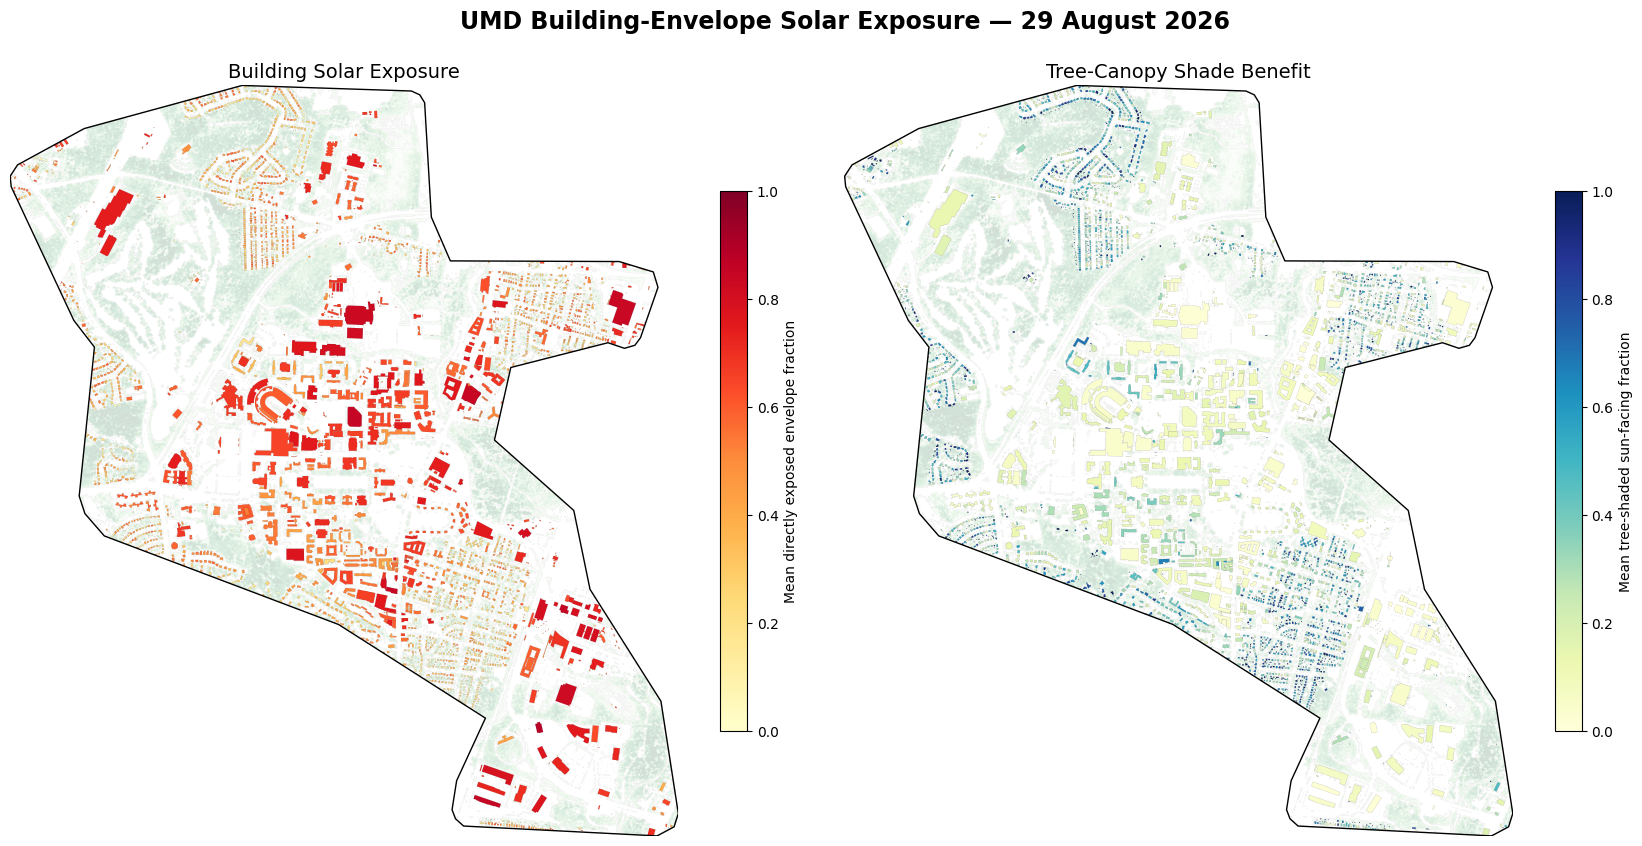

Created: /content/umd-urban-heat-exposure/outputs/figures/umd_building_envelope_exposure.png


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np

# --------------------------------------------------
# Load final exposure data
# --------------------------------------------------

exposure_map = gpd.read_file(
    EXPOSURE_GEOJSON_PATH
).to_crs("EPSG:26918")

envelope_total = exposure_map[
    "envelope_area_m2"
].sum()

roof_total = exposure_map[
    "roof_area_m2"
].sum()

summary_records = []

for hour in [9, 12, 15, 18]:

    suffix = f"{hour:02d}00"

    roof_shaded = exposure_map[
        f"roof_shaded_{suffix}_m2"
    ].sum()

    facade_shaded = exposure_map[
        f"facade_shaded_{suffix}_m2"
    ].sum()

    facade_sun_facing = exposure_map[
        f"facade_sunfacing_{suffix}_m2"
    ].sum()

    tree_shaded = exposure_map[
        f"tree_shaded_{suffix}_m2"
    ].sum()

    direct_sun = exposure_map[
        f"direct_sun_{suffix}_m2"
    ].sum()

    sun_facing_surface = (
        roof_total
        + facade_sun_facing
    )

    weighted_solar_index = (
        (
            exposure_map[
                f"solar_index_{suffix}"
            ]
            * exposure_map[
                "envelope_area_m2"
            ]
        ).sum()
        / envelope_total
    )

    summary_records.append(
        {
            "time": f"{hour:02d}:00",
            "roof_shaded_pct": (
                roof_shaded
                / roof_total
                * 100
            ),
            "facade_shaded_pct_of_sun_facing": (
                facade_shaded
                / facade_sun_facing
                * 100
            ),
            "tree_shade_pct_of_sun_facing": (
                tree_shaded
                / sun_facing_surface
                * 100
            ),
            "envelope_direct_sun_pct": (
                direct_sun
                / envelope_total
                * 100
            ),
            "area_weighted_solar_index": (
                weighted_solar_index
            )
        }
    )

campus_summary = pd.DataFrame(
    summary_records
)

summary_mean = {
    "time": "Four-time mean"
}

for column in campus_summary.columns[1:]:
    summary_mean[column] = (
        campus_summary[column].mean()
    )

campus_summary = pd.concat(
    [
        campus_summary,
        pd.DataFrame([summary_mean])
    ],
    ignore_index=True
)

numeric_columns = campus_summary.columns[
    campus_summary.columns != "time"
]

campus_summary[numeric_columns] = (
    campus_summary[numeric_columns]
    .round(2)
)

print("--- CAMPUS EXPOSURE SUMMARY ---")
display(campus_summary)

SUMMARY_PATH = (
    REPO_DIR
    / "data/processed/umd_exposure_summary_2026-08-29.csv"
)

campus_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print("Created:", SUMMARY_PATH)

# --------------------------------------------------
# Load canopy for background
# --------------------------------------------------

with rasterio.open(CANOPY_PATH) as src:
    canopy_display = src.read(1)
    canopy_bounds = src.bounds

canopy_display = np.ma.masked_where(
    canopy_display < 2,
    canopy_display
)

extent = [
    canopy_bounds.left,
    canopy_bounds.right,
    canopy_bounds.bottom,
    canopy_bounds.top
]

boundary_display = gpd.read_file(
    BOUNDARY_PATH
).to_crs("EPSG:26918")

# --------------------------------------------------
# Continuous exposure maps
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 9)
)

for ax in axes:
    ax.imshow(
        canopy_display,
        extent=extent,
        origin="upper",
        cmap="Greens",
        vmin=2,
        vmax=30,
        alpha=0.18
    )

    boundary_display.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1
    )

    ax.set_axis_off()
    ax.set_aspect("equal")

exposure_map.plot(
    column="mean_exposure_fraction",
    ax=axes[0],
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Mean directly exposed envelope fraction",
        "shrink": 0.65
    }
)

axes[0].set_title(
    "Building Solar Exposure",
    fontsize=14
)

exposure_map.plot(
    column="mean_tree_shade_fraction",
    ax=axes[1],
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Mean tree-shaded sun-facing fraction",
        "shrink": 0.65
    }
)

axes[1].set_title(
    "Tree-Canopy Shade Benefit",
    fontsize=14
)

fig.suptitle(
    "UMD Building-Envelope Solar Exposure — "
    "29 August 2026",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

FIGURE_DIRECTORY = (
    REPO_DIR / "outputs/figures"
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True
)

EXPOSURE_FIGURE_PATH = (
    FIGURE_DIRECTORY
    / "umd_building_envelope_exposure.png"
)

plt.savefig(
    EXPOSURE_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Created:", EXPOSURE_FIGURE_PATH)